In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv("./Tables/Gold/gold_ml_feature_set.csv")

df.head()

,fecha,id_sku,nombre_producto,categoria,cantidad_vendida_total,precio_unitario_promedio,temperatura_promedio,inversion_ads_total,stock_cierre_diario,etl_fecha_carga
0,2024-11-30,SKU_1L,Botella_1L,Personal,262,2.0,20.0,309.44,343,2026-04-26 03:16:07.341521
1,2024-07-30,SKU_1L,Botella_1L,Personal,115,2.0,20.0,61.18,584,2026-04-26 03:16:07.341521
2,2024-08-09,SKU_20L,Bidon_20L,Familiar,89,7.5,20.0,41.24,522,2026-04-26 03:16:07.341521
3,2024-04-24,SKU_1L,Botella_1L,Personal,190,2.0,20.0,166.47,444,2026-04-26 03:16:07.341521
4,2024-11-01,SKU_20L,Bidon_20L,Familiar,247,7.5,20.0,0.00,498,2026-04-26 03:16:07.341521


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 658 entries, 0 to 657
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   fecha                     658 non-null    str    
 1   id_sku                    658 non-null    str    
 2   nombre_producto           658 non-null    str    
 3   categoria                 658 non-null    str    
 4   cantidad_vendida_total    658 non-null    int64  
 5   precio_unitario_promedio  658 non-null    float64
 6   temperatura_promedio      658 non-null    float64
 7   inversion_ads_total       658 non-null    float64
 8   stock_cierre_diario       658 non-null    int64  
 9   etl_fecha_carga           658 non-null    str    
dtypes: float64(3), int64(2), str(5)
memory usage: 51.5 KB


In [4]:
df.describe()

,cantidad_vendida_total,precio_unitario_promedio,temperatura_promedio,inversion_ads_total,stock_cierre_diario
count,658.000000,658.000000,658.0,658.000000,658.000000
mean,240.516717,3.548754,20.0,213.032964,338.095745
std,143.166167,2.873586,0.0,176.934175,166.737724
min,39.000000,0.000000,20.0,0.000000,0.000000
25%,140.000000,1.200000,20.0,90.887500,229.000000
50%,200.500000,2.000000,20.0,180.085000,358.500000
75%,293.500000,7.500000,20.0,280.525000,472.000000
max,949.000000,7.500000,20.0,1180.280000,599.000000


In [5]:
#verificar duplicados
duplicados = df.duplicated().sum()

print("Duplicados:", duplicados)

Duplicados: 0


In [6]:
#cambiar a formato fecha
df['fecha'] = pd.to_datetime(df['fecha'])

In [7]:
#verificar rango temporal
print(df['fecha'].min())
print(df['fecha'].max())

2024-01-01 00:00:00
2024-12-30 00:00:00


In [8]:
#revisar cardinalidad categórica
for col in ['id_sku', 'nombre_producto', 'categoria']:
    print("\n", col)
    print(df[col].value_counts())


 id_sku
id_sku
SKU_20L      235
SKU_500ML    221
SKU_1L       202
Name: count, dtype: int64

 nombre_producto
nombre_producto
Bidon_20L        235
Botella_500ml    221
Botella_1L       202
Name: count, dtype: int64

 categoria
categoria
Personal    423
Familiar    235
Name: count, dtype: int64


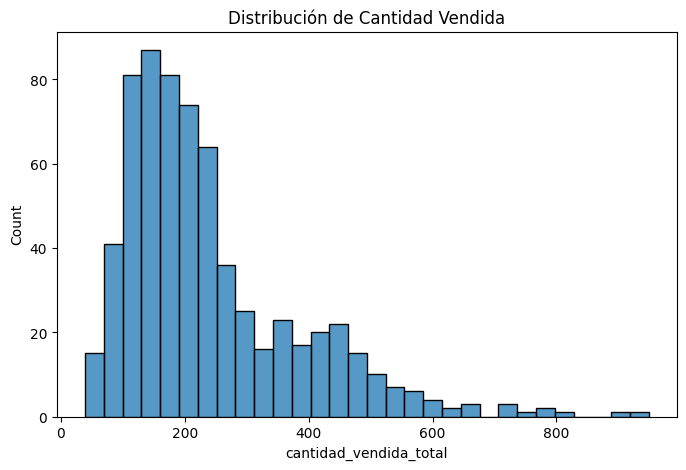

In [9]:
#revisar distribucion target
plt.figure(figsize=(8,5))

sns.histplot(df['cantidad_vendida_total'], bins=30)

plt.title("Distribución de Cantidad Vendida")
plt.show()

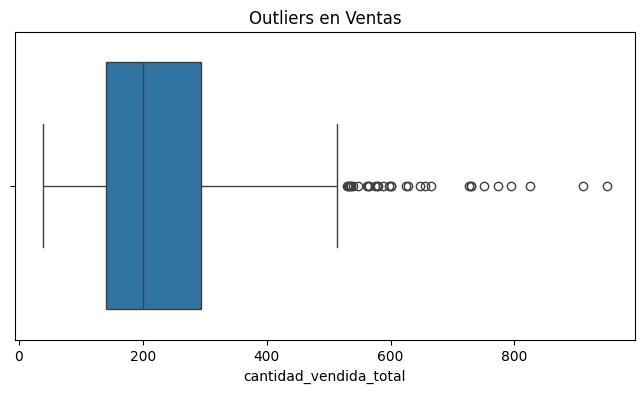

In [10]:
#boxplot ventas
plt.figure(figsize=(8,4))

sns.boxplot(x=df['cantidad_vendida_total'])

plt.title("Outliers en Ventas")
plt.show()

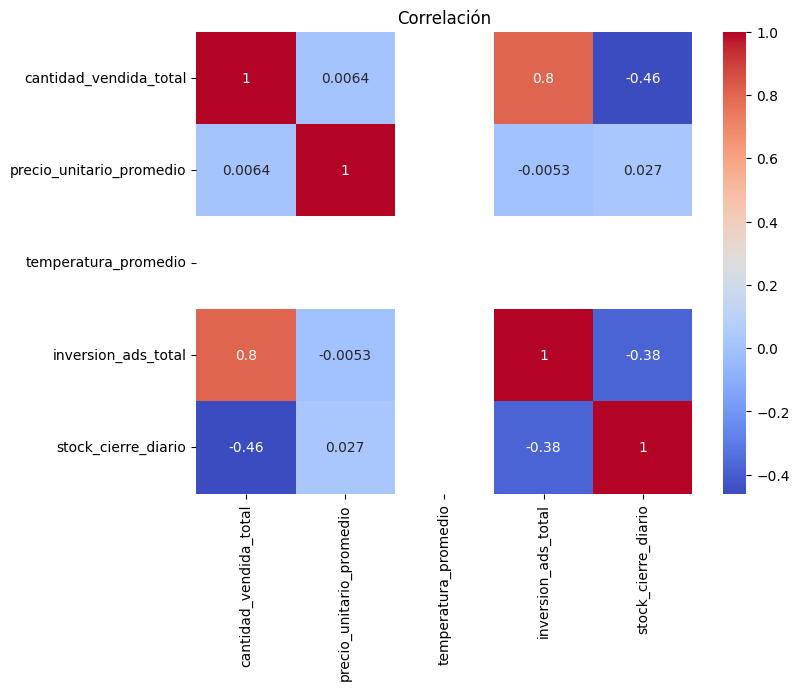

In [11]:
#correlacion numerica
corr = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlación")
plt.show()

In [12]:
df = df.drop(columns=[
    'nombre_producto',
    'temperatura_promedio'
])
df.head()

,fecha,id_sku,categoria,cantidad_vendida_total,precio_unitario_promedio,inversion_ads_total,stock_cierre_diario,etl_fecha_carga
0,2024-11-30,SKU_1L,Personal,262,2.0,309.44,343,2026-04-26 03:16:07.341521
1,2024-07-30,SKU_1L,Personal,115,2.0,61.18,584,2026-04-26 03:16:07.341521
2,2024-08-09,SKU_20L,Familiar,89,7.5,41.24,522,2026-04-26 03:16:07.341521
3,2024-04-24,SKU_1L,Personal,190,2.0,166.47,444,2026-04-26 03:16:07.341521
4,2024-11-01,SKU_20L,Familiar,247,7.5,0.00,498,2026-04-26 03:16:07.341521


In [13]:
#ordenar temporalmente
df = df.sort_values(['id_sku', 'fecha'])

In [14]:
#eliminar etl_ fecha carga
df = df.drop(columns=[
    'etl_fecha_carga'
])

In [15]:
#feature engineering
df['dia_semana'] = df['fecha'].dt.dayofweek

In [16]:
#mes
df['mes'] = df['fecha'].dt.month

In [17]:
#fin de semana
df['es_fin_semana'] = (
    df['dia_semana']
    .isin([5,6])
    .astype(int)
)

In [18]:
# crear lags de venta
df['ventas_lag1'] = (
    df.groupby('id_sku')['cantidad_vendida_total']
    .shift(1)
)

In [19]:
#ventas hace 7 dias
df['ventas_lag7'] = (
    df.groupby('id_sku')['cantidad_vendida_total']
    .shift(7)
)

In [20]:
#rolling mean promedio movil semanal
df['ventas_roll7'] = (
    df.groupby('id_sku')['cantidad_vendida_total']
    .transform(lambda x: x.rolling(7).mean())
)

In [21]:
df.head(15)

,fecha,id_sku,categoria,cantidad_vendida_total,precio_unitario_promedio,inversion_ads_total,stock_cierre_diario,dia_semana,mes,es_fin_semana,ventas_lag1,ventas_lag7,ventas_roll7
26,2024-01-01,SKU_1L,Personal,279,2.0,0.00,443,0,1,0,NaN,NaN,NaN
276,2024-01-02,SKU_1L,Personal,244,2.0,289.13,218,1,1,0,279.0,NaN,NaN
511,2024-01-03,SKU_1L,Personal,259,2.0,273.50,0,2,1,0,244.0,NaN,NaN
635,2024-01-04,SKU_1L,Personal,101,2.0,74.82,443,3,1,0,259.0,NaN,NaN
188,2024-01-09,SKU_1L,Personal,208,2.0,211.24,488,1,1,0,101.0,NaN,NaN
375,2024-01-10,SKU_1L,Personal,102,2.0,0.00,295,2,1,0,208.0,NaN,NaN
284,2024-01-12,SKU_1L,Personal,499,2.0,513.14,0,4,1,0,102.0,NaN,241.714286
149,2024-01-14,SKU_1L,Personal,196,2.0,248.05,360,6,1,1,499.0,279.0,229.857143
479,2024-01-15,SKU_1L,Personal,114,2.0,98.92,556,0,1,0,196.0,244.0,211.285714
35,2024-01-19,SKU_1L,Personal,450,2.0,531.38,0,4,1,0,114.0,259.0,238.571429


In [22]:
#verificar nulos
df.isnull().sum()

fecha                        0
id_sku                       0
categoria                    0
cantidad_vendida_total       0
precio_unitario_promedio     0
inversion_ads_total          0
stock_cierre_diario          0
dia_semana                   0
mes                          0
es_fin_semana                0
ventas_lag1                  3
ventas_lag7                 21
ventas_roll7                18
dtype: int64

In [23]:
#eliminar nulos de lags
df = df.dropna()

In [24]:
df.info()

<class 'pandas.DataFrame'>
Index: 637 entries, 149 to 637
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   fecha                     637 non-null    datetime64[us]
 1   id_sku                    637 non-null    str           
 2   categoria                 637 non-null    str           
 3   cantidad_vendida_total    637 non-null    int64         
 4   precio_unitario_promedio  637 non-null    float64       
 5   inversion_ads_total       637 non-null    float64       
 6   stock_cierre_diario       637 non-null    int64         
 7   dia_semana                637 non-null    int32         
 8   mes                       637 non-null    int32         
 9   es_fin_semana             637 non-null    int64         
 10  ventas_lag1               637 non-null    float64       
 11  ventas_lag7               637 non-null    float64       
 12  ventas_roll7              637 non-nu

In [25]:
df.head()

,fecha,id_sku,categoria,cantidad_vendida_total,precio_unitario_promedio,inversion_ads_total,stock_cierre_diario,dia_semana,mes,es_fin_semana,ventas_lag1,ventas_lag7,ventas_roll7
149,2024-01-14,SKU_1L,Personal,196,2.0,248.05,360,6,1,1,499.0,279.0,229.857143
479,2024-01-15,SKU_1L,Personal,114,2.0,98.92,556,0,1,0,196.0,244.0,211.285714
35,2024-01-19,SKU_1L,Personal,450,2.0,531.38,0,4,1,0,114.0,259.0,238.571429
206,2024-01-20,SKU_1L,Personal,179,2.0,225.82,455,5,1,1,450.0,101.0,249.714286
288,2024-01-21,SKU_1L,Personal,229,2.0,244.97,267,6,1,1,179.0,208.0,252.714286


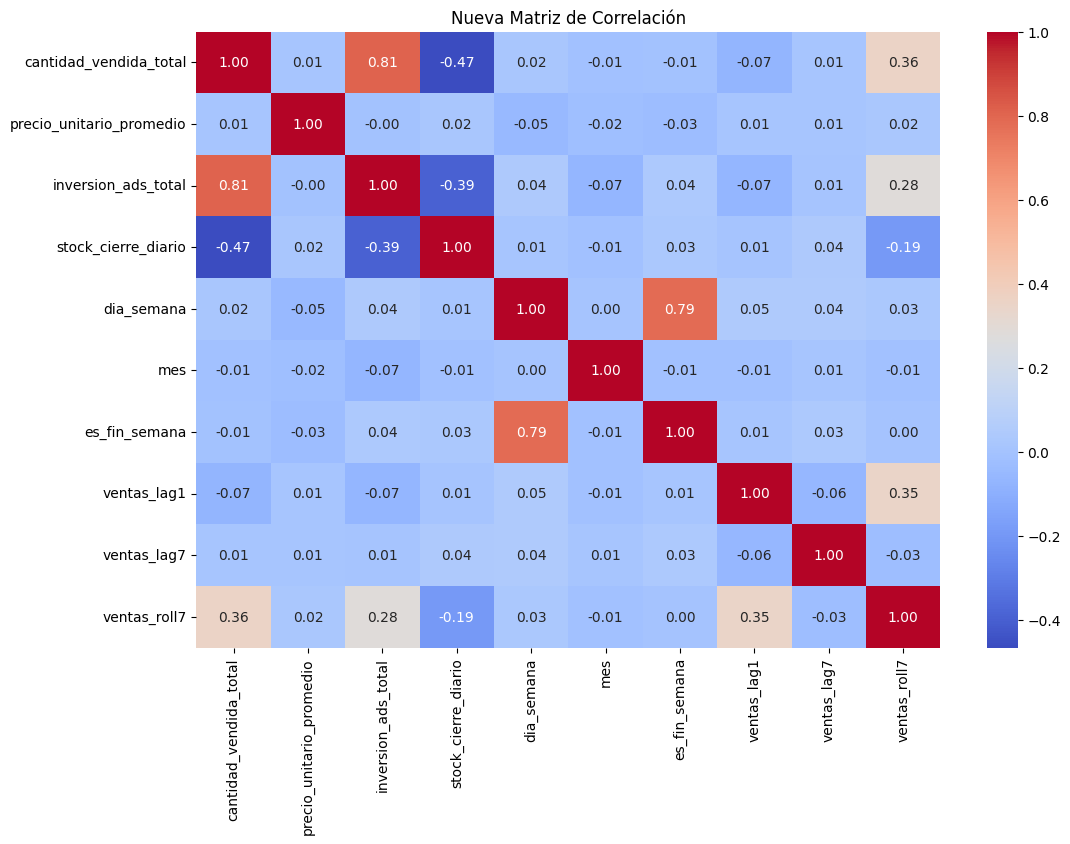

In [26]:
#nueva correlacion
# seleccionar solo variables numéricas
corr = df.select_dtypes(include=np.number).corr()

# graficar heatmap
plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Nueva Matriz de Correlación")
plt.show()

In [27]:
#correlacion con ventas
corr_target = (
    df.select_dtypes(include=np.number)
    .corr()['cantidad_vendida_total']
    .sort_values(ascending=False)
)

print(corr_target)

cantidad_vendida_total      1.000000
inversion_ads_total         0.808856
ventas_roll7                0.358386
dia_semana                  0.019625
precio_unitario_promedio    0.012562
ventas_lag7                 0.009631
es_fin_semana              -0.007197
mes                        -0.009023
ventas_lag1                -0.074375
stock_cierre_diario        -0.465690
Name: cantidad_vendida_total, dtype: float64


In [28]:
#eliminado variables con baja correlacion
df_model = df.drop(columns=[
    'precio_unitario_promedio',
    'mes',
    'es_fin_semana'
])

In [29]:
#definimos target y features
X = df_model.drop(columns=[
    'cantidad_vendida_total',
    'fecha'
])

y = df_model['cantidad_vendida_total']

In [30]:
#split temporal
split_index = int(len(df_model)*0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

In [31]:
#verificar tamaños
print(X_train.shape)
print(X_test.shape)

(509, 8)
(128, 8)


In [32]:
#variables numericas y categoricas
numerical_features = [
    'inversion_ads_total',
    'stock_cierre_diario',
    'dia_semana',
    'ventas_lag1',
    'ventas_lag7',
    'ventas_roll7'
]

categorical_features = [
    'id_sku',
    'categoria'
]

In [33]:
#preprocesamiento
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

In [34]:
#dataset transformado
preprocessor.fit(X_train)

X_train_transformed = preprocessor.transform(X_train)

columns_transformed = preprocessor.get_feature_names_out()

X_train_processed = pd.DataFrame(
    X_train_transformed,
    columns=columns_transformed,
    index=X_train.index
)

X_train_processed.head()

,num__inversion_ads_total,num__stock_cierre_diario,num__dia_semana,num__ventas_lag1,num__ventas_lag7,num__ventas_roll7,cat__id_sku_SKU_1L,cat__id_sku_SKU_20L,cat__id_sku_SKU_500ML,cat__categoria_Familiar,cat__categoria_Personal
149,0.173504,0.123362,1.500446,1.805363,0.261408,-0.281408,1.0,0.0,0.0,0.0,1.0
479,-0.688677,1.295238,-1.450206,-0.342183,0.012078,-0.649021,1.0,0.0,0.0,0.0,1.0
35,1.811549,-2.029064,0.516895,-0.923366,0.118934,-0.108912,1.0,0.0,0.0,0.0,1.0
206,0.044983,0.691363,1.008671,1.458070,-1.006611,0.111656,1.0,0.0,0.0,0.0,1.0
288,0.155697,-0.432682,1.500446,-0.462672,-0.244375,0.171040,1.0,0.0,0.0,0.0,1.0


In [35]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(
            handle_unknown='ignore',
            drop='first'
        ), categorical_features)
    ]
)

In [36]:
#dataset transformado
preprocessor.fit(X_train)

X_train_transformed = preprocessor.transform(X_train)

columns_transformed = preprocessor.get_feature_names_out()

X_train_processed = pd.DataFrame(
    X_train_transformed,
    columns=columns_transformed,
    index=X_train.index
)

X_train_processed.head()

,num__inversion_ads_total,num__stock_cierre_diario,num__dia_semana,num__ventas_lag1,num__ventas_lag7,num__ventas_roll7,cat__id_sku_SKU_20L,cat__id_sku_SKU_500ML,cat__categoria_Personal
149,0.173504,0.123362,1.500446,1.805363,0.261408,-0.281408,0.0,0.0,1.0
479,-0.688677,1.295238,-1.450206,-0.342183,0.012078,-0.649021,0.0,0.0,1.0
35,1.811549,-2.029064,0.516895,-0.923366,0.118934,-0.108912,0.0,0.0,1.0
206,0.044983,0.691363,1.008671,1.458070,-1.006611,0.111656,0.0,0.0,1.0
288,0.155697,-0.432682,1.500446,-0.462672,-0.244375,0.171040,0.0,0.0,1.0


In [37]:
#modelos
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    )
}

In [38]:
#entrenamiento
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

results = []

for name, model in models.items():
    
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    pipeline.fit(X_train, y_train)
    
    y_pred = pipeline.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    
    rmse = np.sqrt(
        mean_squared_error(y_test, y_pred)
    )
    
    r2 = r2_score(y_test, y_pred)
    
    results.append({
        "Modelo": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

results_df = pd.DataFrame(results)

results_df

,Modelo,MAE,RMSE,R2
0,Linear Regression,49.523180,71.314727,0.786266
1,Random Forest,43.554766,60.578156,0.845778
2,Gradient Boosting,41.209776,56.128580,0.867602


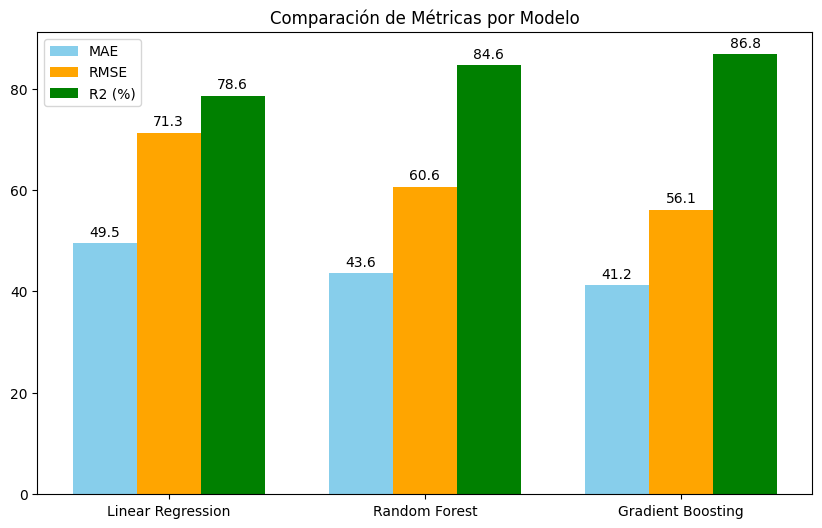

In [39]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(10,6))

x = np.arange(len(results_df["Modelo"]))
width = 0.25

bars1 = ax.bar(
    x - width,
    results_df["MAE"],
    width,
    label='MAE',
    color='skyblue'
)

bars2 = ax.bar(
    x,
    results_df["RMSE"],
    width,
    label='RMSE',
    color='orange'
)

bars3 = ax.bar(
    x + width,
    results_df["R2"]*100,
    width,
    label='R2 (%)',
    color='green'
)

ax.set_xticks(x)
ax.set_xticklabels(results_df["Modelo"])

ax.set_title("Comparación de Métricas por Modelo")
ax.legend()

# etiquetas
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(
            f'{height:.1f}',
            xy=(bar.get_x() + bar.get_width()/2, height),
            xytext=(0,3),
            textcoords="offset points",
            ha='center',
            va='bottom'
        )

plt.show()

Interpretación

Gradient Boosting obtuvo el mejor desempeño general.

El modelo consiguió explicar aproximadamente:

86.8%

de la variabilidad de la demanda.

Esto representa un desempeño muy sólido para un problema de forecasting retail.

Además:

obtuvo el menor error promedio
tuvo el menor RMSE
mostró mejor capacidad de generalización

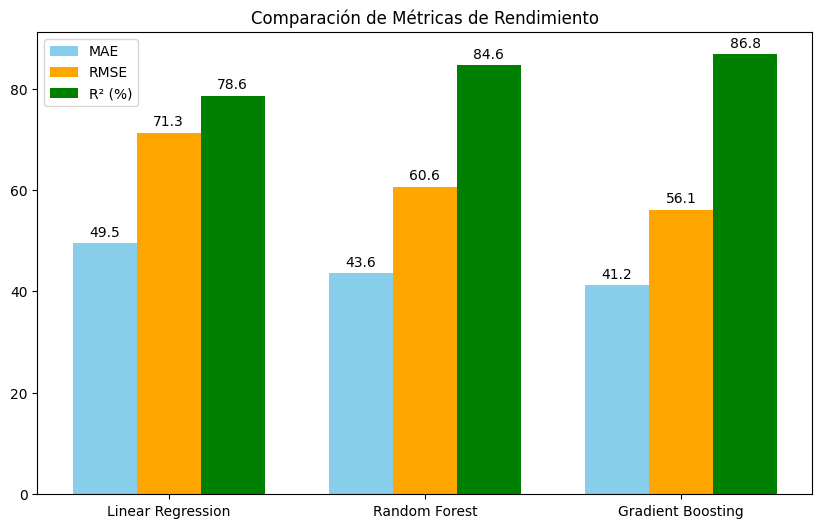

In [40]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(10,6))

x = np.arange(len(results_df["Modelo"]))
width = 0.25

bars1 = ax.bar(
    x - width,
    results_df["MAE"],
    width,
    label='MAE',
    color='skyblue'
)

bars2 = ax.bar(
    x,
    results_df["RMSE"],
    width,
    label='RMSE',
    color='orange'
)

bars3 = ax.bar(
    x + width,
    results_df["R2"]*100,
    width,
    label='R² (%)',
    color='green'
)

ax.set_xticks(x)
ax.set_xticklabels(results_df["Modelo"])

ax.set_title("Comparación de Métricas de Rendimiento")
ax.legend()

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(
            f'{height:.1f}',
            xy=(bar.get_x() + bar.get_width()/2, height),
            xytext=(0,3),
            textcoords="offset points",
            ha='center',
            va='bottom'
        )

plt.show()

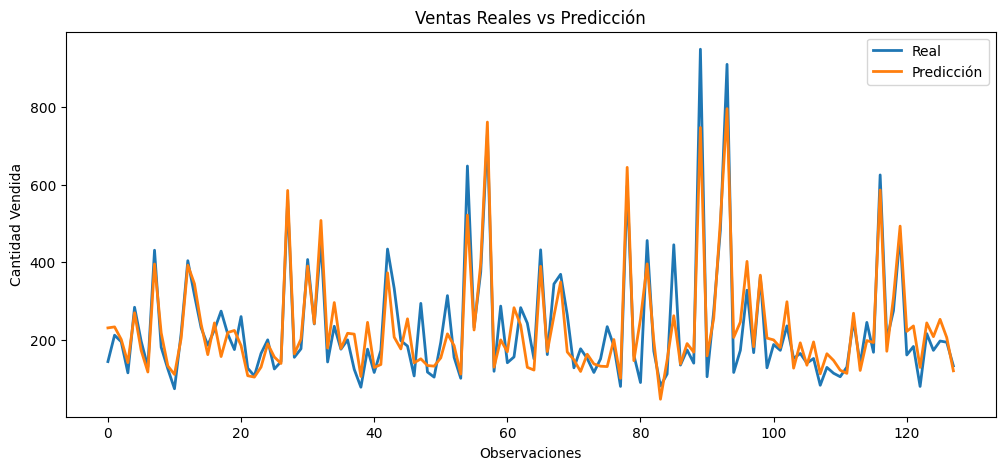

In [41]:
#prediciones vs reales
best_model = GradientBoostingRegressor(random_state=42)

pipeline_best = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', best_model)
])

pipeline_best.fit(X_train, y_train)

y_pred = pipeline_best.predict(X_test)

plt.figure(figsize=(12,5))

plt.plot(
    y_test.values,
    label="Real",
    linewidth=2
)

plt.plot(
    y_pred,
    label="Predicción",
    linewidth=2
)

plt.title("Ventas Reales vs Predicción")
plt.xlabel("Observaciones")
plt.ylabel("Cantidad Vendida")

plt.legend()

plt.show()

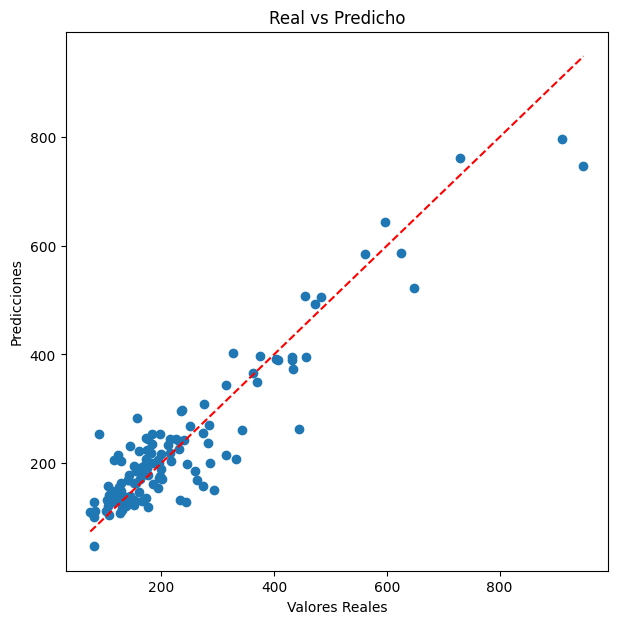

In [42]:
#dispersion real vs predicho
plt.figure(figsize=(7,7))

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Valores Reales")
plt.ylabel("Predicciones")

plt.title("Real vs Predicho")

plt.show()

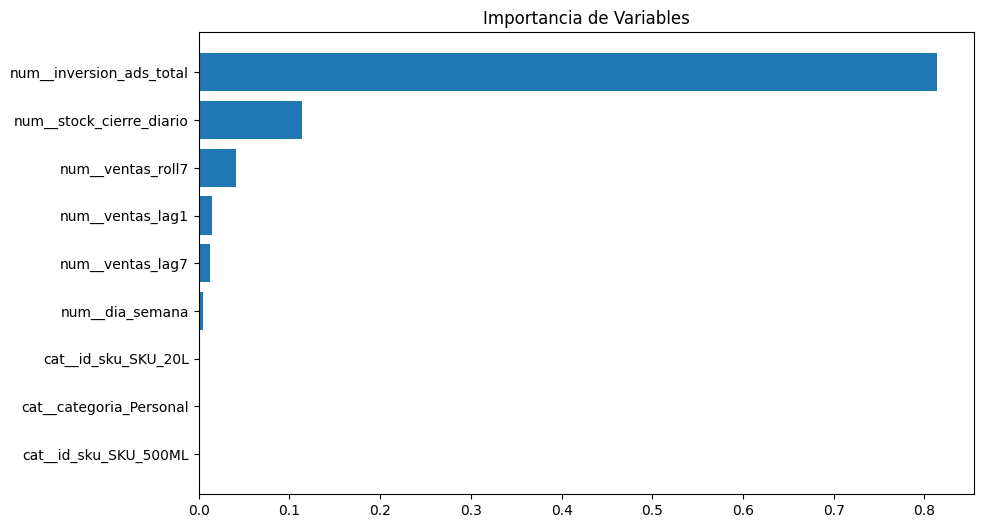

,feature,importance
0,num__inversion_ads_total,0.813595
1,num__stock_cierre_diario,0.113643
5,num__ventas_roll7,0.041491
3,num__ventas_lag1,0.014366
4,num__ventas_lag7,0.011929
2,num__dia_semana,0.004886
6,cat__id_sku_SKU_20L,0.000051
8,cat__categoria_Personal,0.000040
7,cat__id_sku_SKU_500ML,0.000000


In [43]:
#importancia de variables
model = pipeline_best.named_steps['model']

feature_names = (
    pipeline_best.named_steps['preprocessor']
    .get_feature_names_out()
)

importance = model.feature_importances_

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importance
})

importance_df = importance_df.sort_values(
    by='importance',
    ascending=False
)

plt.figure(figsize=(10,6))

plt.barh(
    importance_df['feature'],
    importance_df['importance']
)

plt.gca().invert_yaxis()

plt.title("Importancia de Variables")

plt.show()

importance_df.head(10)

In [44]:
#hiperparametros
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor

pipeline_gb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', GradientBoostingRegressor(random_state=42))
])

param_grid = {
    'model__n_estimators': [100, 200],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__max_depth': [2, 3, 4],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf': [1, 2]
}

grid_search = GridSearchCV(
    pipeline_gb,
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 72 candidates, totalling 360 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__learning_rate': [0.01, 0.05, ...], 'model__max_depth': [2, 3, ...], 'model__min_samples_leaf': [1, 2], 'model__min_samples_split': [2, 5], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation tim

In [45]:
#mejores parametros
print(grid_search.best_params_)

{'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 100}


In [46]:
#mejor score cv
print(grid_search.best_score_)

0.8267836096734535


In [47]:
#evaluar modelo optimizado
best_model = grid_search.best_estimator_

y_pred_opt = best_model.predict(X_test)

mae_opt = mean_absolute_error(y_test, y_pred_opt)

rmse_opt = np.sqrt(
    mean_squared_error(y_test, y_pred_opt)
)

r2_opt = r2_score(y_test, y_pred_opt)

print("MAE:", mae_opt)
print("RMSE:", rmse_opt)
print("R2:", r2_opt)

MAE: 40.10573310460598
RMSE: 55.8108702518027
R2: 0.8690963436348458


In [48]:
#comparacion baseline vs optimized
comparison_df = pd.DataFrame({
    'Metrica': ['MAE', 'RMSE', 'R2'],
    'Baseline': [
        41.21,
        56.13,
        0.868
    ],
    'Optimizado': [
        mae_opt,
        rmse_opt,
        r2_opt
    ]
})

comparison_df

,Metrica,Baseline,Optimizado
0,MAE,41.210,40.105733
1,RMSE,56.130,55.810870
2,R2,0.868,0.869096


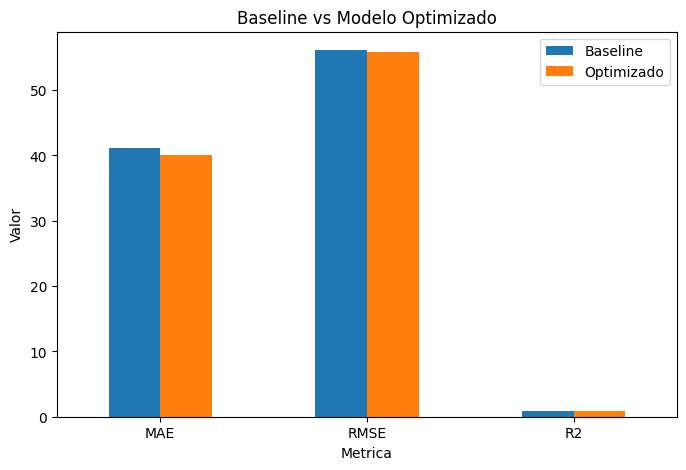

In [49]:
comparison_plot = comparison_df.set_index('Metrica')

comparison_plot.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Baseline vs Modelo Optimizado")

plt.ylabel("Valor")

plt.xticks(rotation=0)

plt.show()

In [50]:
import joblib

# guardar pipeline completo
joblib.dump(
    best_model,
    "modelo_forecasting.pkl"
)

print("Modelo guardado correctamente")

Modelo guardado correctamente
